<a href="https://colab.research.google.com/github/incable1560/MLF_228046_Ondrej_Hrozek/blob/main/Cv.8-31.3.2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [314]:
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Flatten, SimpleRNN

### 1.1 Generating dataset

In [315]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [316]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [317]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [318]:
no_training_epochs = 5

### 1.3 Data examination

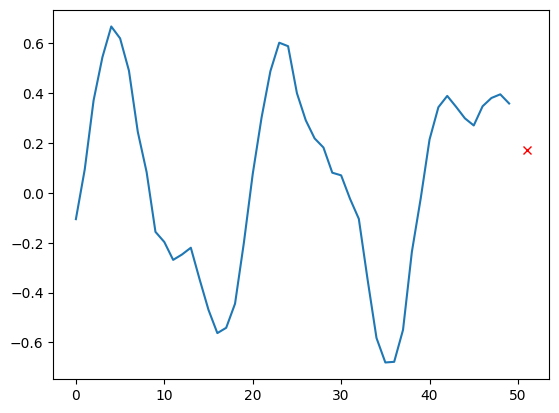

In [319]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [320]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

In [321]:
# Model building

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [322]:
model_linear.summary()

Model: "sequential_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [323]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1448 - mean_squared_error: 0.1448 - val_loss: 0.0402 - val_mean_squared_error: 0.0402
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0287 - mean_squared_error: 0.0287 - val_loss: 0.0212 - val_mean_squared_error: 0.0212
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0173 - mean_squared_error: 0.0173 - val_loss: 0.0143 - val_mean_squared_error: 0.0143
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0128 - mean_squared_error: 0.0128 - val_loss: 0.0113 - val_mean_squared_error: 0.0113
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0096 - val_mean_squared_error: 0.0096


In [324]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

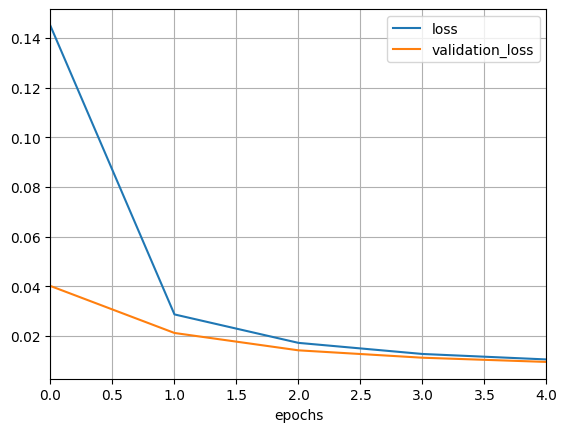

In [325]:
plot_function(history_linear)

In [326]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.009048735722899437
Test MSE:  0.009048735722899437


### 1.5 Simple RNN Model

In [327]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [328]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [329]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.1693 - mean_squared_error: 0.1693 - val_loss: 0.1182 - val_mean_squared_error: 0.1182
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1073 - mean_squared_error: 0.1073 - val_loss: 0.0904 - val_mean_squared_error: 0.0904
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0823 - mean_squared_error: 0.0823 - val_loss: 0.0699 - val_mean_squared_error: 0.0699
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0646 - mean_squared_error: 0.0646 - val_loss: 0.0565 - val_mean_squared_error: 0.0565
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0529 - mean_squared_error: 0.0529 - val_loss: 0.0473 - val_mean_squared_error: 0.0473


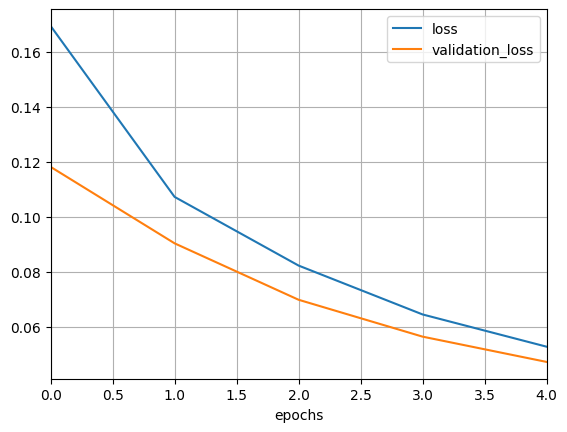

In [330]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [331]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [332]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [333]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.0350 - mean_squared_error: 0.0350 - val_loss: 0.0080 - val_mean_squared_error: 0.0080
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0068 - mean_squared_error: 0.0068 - val_loss: 0.0057 - val_mean_squared_error: 0.0057
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0052 - mean_squared_error: 0.0052 - val_loss: 0.0042 - val_mean_squared_error: 0.0042
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0041 - val_mean_squared_error: 0.0041
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0036 - val_mean_squared_error: 0.0036


In [334]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.003756109159439802
Test MSE:  0.003756109159439802


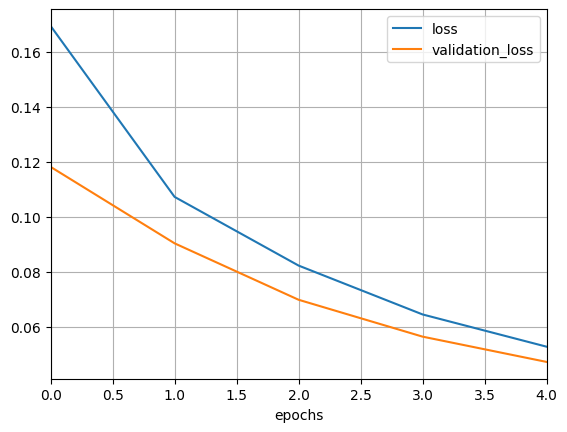

In [335]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [336]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

### 2.1 - Load dataset

In [337]:
vocabulary_size = 10000

(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=vocabulary_size)

max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

callbacks = [keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]

### 2.2 - Dataset examination

In [338]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

In [339]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [340]:
single_sequence

"and you could just imagine being there robert <unk> is an amazing actor and now the same being director <unk> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <unk> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <unk> to the two little boy's that played the <unk> of norman and paul they were just brilliant children are often left out of the <unk> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you think the whole story was so lovely because it was true and was someone's life after all that wa

In [341]:
embed_size = 128

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])

In [342]:
optimizer = Adam(learning_rate=0.001)

In [343]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [344]:
history = model.fit(X_train, y_train, epochs=20, validation_split=0.2, callbacks=callbacks)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.5990 - loss: 0.6417 - val_accuracy: 0.7588 - val_loss: 0.5079
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.7865 - loss: 0.4699 - val_accuracy: 0.8060 - val_loss: 0.4946
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.8195 - loss: 0.4161 - val_accuracy: 0.7696 - val_loss: 0.4911
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.8155 - loss: 0.4167 - val_accuracy: 0.7746 - val_loss: 0.4807
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.8148 - loss: 0.4158 - val_accuracy: 0.7976 - val_loss: 0.4556
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.8626 - loss: 0.3359 - val_accuracy: 0.5464 - val_loss: 0.6856
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.8134 - loss: 0.4230 - val_accuracy: 0.7286 - val_loss: 0.6070
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.6896 - loss: 0.5768 - 

In [345]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Test loss: 0.4469583332538605
Test accuracy:  79.94800209999084 %


TASK: Modify structure, change the core of the network from RNN to LTSM and GRU. Compare the results

In [346]:
model_lstm = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, 128, input_length=max_length),

    keras.layers.Bidirectional(
        keras.layers.LSTM(128, return_sequences=True)
    ),

    keras.layers.Bidirectional(
        keras.layers.LSTM(64)
    ),

    keras.layers.Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001)

model_lstm.compile(loss="binary_crossentropy",optimizer=optimizer,metrics=["accuracy"])

history_lstm = model_lstm.fit(X_train, y_train, epochs=20, validation_split=0.2, callbacks=callbacks)

score_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)

print('LSTM Test loss:', score_lstm[0])
print('LSTM Test accuracy:', score_lstm[1]*100, "%")

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.7643 - loss: 0.4847 - val_accuracy: 0.8606 - val_loss: 0.3385
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.8795 - loss: 0.2970 - val_accuracy: 0.8586 - val_loss: 0.3341
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.9251 - loss: 0.2014 - val_accuracy: 0.8732 - val_loss: 0.3445
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.9473 - loss: 0.1462 - val_accuracy: 0.8638 - val_loss: 0.3650
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.9622 - loss: 0.1066 - val_accuracy: 0.8612 - val_loss: 0.4333
LSTM Test loss: 0.33405277132987976
LSTM Test accuracy: 85.96000075340271 %


In [347]:
model_gru = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, 128, input_length=max_length),

    keras.layers.Bidirectional(
        keras.layers.GRU(128, return_sequences=True)
    ),

    keras.layers.Bidirectional(
        keras.layers.GRU(64)
    ),

    keras.layers.Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001)

model_gru.compile(loss="binary_crossentropy",optimizer=optimizer,metrics=["accuracy"])

history_gru = model_gru.fit(X_train, y_train, epochs=20, validation_split=0.2, callbacks=callbacks)

score_gru = model_gru.evaluate(X_test, y_test, verbose=0)

print('GRU Test loss:', score_gru[0])
print('GRU Test accuracy:', score_gru[1]*100, "%")

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.7628 - loss: 0.4815 - val_accuracy: 0.8474 - val_loss: 0.3495
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.8928 - loss: 0.2671 - val_accuracy: 0.8738 - val_loss: 0.3005
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9416 - loss: 0.1587 - val_accuracy: 0.8706 - val_loss: 0.3246
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.9708 - loss: 0.0893 - val_accuracy: 0.8730 - val_loss: 0.3972
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.9834 - loss: 0.0501 - val_accuracy: 0.8558 - val_loss: 0.5345
GRU Test loss: 0.30562570691108704
GRU Test accuracy: 87.29199767112732 %
